# Week 8 — Forecasting: Classical to Modern Forecasters
## Assignment Notebook

**Dataset:** Monthly S&P 500 Index 1990–2024 (downloaded via `yfinance`)

**Instructions:** Every `= None` in a code cell is a value you must compute.
Replace `None` with your expression — do not change the variable name.
All SELF-CHECK assertions must pass before submission.

**Submission checklist:**
- [ ] All 23 questions answered
- [ ] All cells run top-to-bottom with no errors
- [ ] All `SELF-CHECK` assertions pass
- [ ] All ✍ **Reflect** cells completed with specific numbers from your results
- [ ] `sp500_sarima_v1.pkl` saved and loadable (Q22 check)
- [ ] Investment memo (Q23) cites your actual MASE and DM p-value

**Parts:**
1. Data Preparation (Q1–Q5)
2. Classical Models + SARIMA (Q6–Q10)
3. Prophet (Q11–Q12)
4. Feature Engineering + ML (Q13–Q16)
5. Deep Learning (Q17–Q18)
6. Evaluation & Comparison (Q19–Q22)
7. Investment Recommendation (Q23)


## Setup — run these cells before anything else

In [2]:
# Install all required libraries (run once; restart kernel if prompted)
# !pip install -q yfinance prophet lightgbm xgboost tensorflow statsmodels

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings, pickle, os
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools     import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.holtwinters   import ExponentialSmoothing
from statsmodels.stats.diagnostic  import acorr_ljungbox
from scipy.stats                   import ttest_1samp
from sklearn.model_selection       import TimeSeriesSplit
from sklearn.linear_model          import LinearRegression
from sklearn.preprocessing         import MinMaxScaler
from sklearn.neural_network        import MLPRegressor

plt.rcParams.update({'figure.dpi': 110, 'axes.spines.right': False,
                     'axes.spines.top': False})
print("✅ Imports ready")

✅ Imports ready


In [4]:
# ── Data loading — do NOT modify ──────────────────────────────────────────────
import yfinance as yf
raw = yf.download('^GSPC', start='1990-01-01', end='2024-12-31',
                  interval='1mo', auto_adjust=True, progress=False)
series = raw['Close'].squeeze().rename('SP500')  # closing price
idx = pd.to_datetime(series.index)
idx = idx.tz_convert(None) if idx.tz is not None else idx
series.index = idx.as_unit('ns')
series.index.freq = 'MS'
print(f"✅ yfinance: {len(series)} monthly observations")

TRAIN_END  = '2019-12'
TEST_START = '2020-01'
train     = series[:TRAIN_END]
test      = series[TEST_START:]
log_train = np.log(train)
H         = len(test)
print(f"Train: {len(train)} months  |  Test: {len(test)} months  |  H={H}")

# ── Metric helper — do NOT modify ─────────────────────────────────────────────
def compute_metrics(actual, predicted, train_actual, s=12):
    a = np.array(actual); p = np.array(predicted); e = a - p
    naive_err = np.abs(train_actual.values[s:] - train_actual.values[:-s])
    mae   = np.abs(e).mean()
    rmse  = np.sqrt((e**2).mean())
    mape_ = (np.abs(e / a)).mean() * 100
    smape = (np.abs(e) / ((np.abs(a) + np.abs(p)) / 2)).mean() * 100
    wmae  = (np.abs(e) * a).sum() / a.sum()
    wmape = (np.abs(e / a) * a).sum() / a.sum() * 100
    mase_ = mae / naive_err.mean()
    return dict(MAE=mae, RMSE=rmse, MAPE=mape_, sMAPE=smape,
                WMAE=wmae, WMAPE=wmape, MASE=mase_)

results = {}   # {model_name: np.array of length H}

✅ yfinance: 420 monthly observations
Train: 360 months  |  Test: 60 months  |  H=60


In [5]:
raw.head()

Price,Close,High,Low,Open,Volume
Ticker,^GSPC,^GSPC,^GSPC,^GSPC,^GSPC
Date,,,,,
1990-01-01,329.079987,360.589996,319.829987,353.399994,3793250000
1990-02-01,331.890015,336.089996,322.100006,329.079987,2961970000
1990-03-01,339.940002,344.489990,331.079987,331.890015,3283280000
1990-04-01,330.799988,347.299988,327.760010,339.940002,2801220000
1990-05-01,361.230011,362.260010,330.799988,330.799988,3596680000


In [6]:
series.head()   # Monthly closing prices

,SP500
Date,
1990-01-01,329.079987
1990-02-01,331.890015
1990-03-01,339.940002
1990-04-01,330.799988
1990-05-01,361.230011


---
## Part 1 — Data Preparation (Q1–Q5)


### Q1 — Verify the DatetimeIndex

Before any modelling confirm three things about `series`:
- `index.dtype` is `datetime64[ns]`
- `index.freq` is `'MS'` (Month Start)
- At least 300 monthly observations


In [7]:
# Q1 ──────────────────────────────────────────────────────────────────────────
index_dtype = series.index   # data type of series.index
index_freq  = series.index.freqstr   # standard frequency string from series.index.freqstr
n_obs       = len(series)   # total number of observations in series

print("dtype :", index_dtype)
print("freq  :", index_freq)
print("len   :", n_obs)
print(f"\nTrain: {train.index[0].date()} → {train.index[-1].date()} ({len(train)} months)")
print(f"Test : {test.index[0].date()} → {test.index[-1].date()} ({len(test)} months)")

dtype : DatetimeIndex(['1990-01-01', '1990-02-01', '1990-03-01', '1990-04-01',
               '1990-05-01', '1990-06-01', '1990-07-01', '1990-08-01',
               '1990-09-01', '1990-10-01',
               ...
               '2024-03-01', '2024-04-01', '2024-05-01', '2024-06-01',
               '2024-07-01', '2024-08-01', '2024-09-01', '2024-10-01',
               '2024-11-01', '2024-12-01'],
              dtype='datetime64[ns]', name='Date', length=420, freq='MS')
freq  : MS
len   : 420

Train: 1990-01-01 → 2019-12-01 (360 months)
Test : 2020-01-01 → 2024-12-01 (60 months)


In [8]:
# SELF-CHECK
assert series.index.dtype == 'datetime64[ns]', "Index must be datetime64[ns]"
assert series.index.freqstr == 'MS',           "Frequency must be MS"
assert len(series) >= 300,                     "Expected ≥ 300 observations"
print("✅ Q1 passed")

✅ Q1 passed


✍ **Reflect:** What does `freq='MS'` mean? What would happen to `.shift()` and `.rolling()` operations if the index had no frequency set?
- `freq='MS'` Means frequency is from starting of the Month

### Q2 — Resample to quarterly and annual

Use `.resample().last()` to extract quarterly and annual end-prices.
Then find which decade had the highest mean quarterly log-return.


In [9]:
print("Checking Null values:", log_train.isna().sum())

Checking Null values: 0


In [10]:
train.resample(rule='QE').last().head(), train.resample(rule='YE').last().head()

(Date
 1990-03-31    339.940002
 1990-06-30    358.019989
 1990-09-30    306.049988
 1990-12-31    330.220001
 1991-03-31    375.220001
 Freq: QE-DEC, Name: SP500, dtype: float64,
 Date
 1990-12-31    330.220001
 1991-12-31    417.089996
 1992-12-31    435.709991
 1993-12-31    466.450012
 1994-12-31    459.269989
 Freq: YE-DEC, Name: SP500, dtype: float64)

In [11]:
log_train.resample(rule='QE').last().head()

,SP500
Date,
1990-03-31,5.828769
1990-06-30,5.880589
1990-09-30,5.723748
1990-12-31,5.799759
1991-03-31,5.927513


Mean quarterly log-return by decade:
 Date
1990    0.0375
2000   -0.0069
2010    0.0266
Name: SP500, dtype: float64


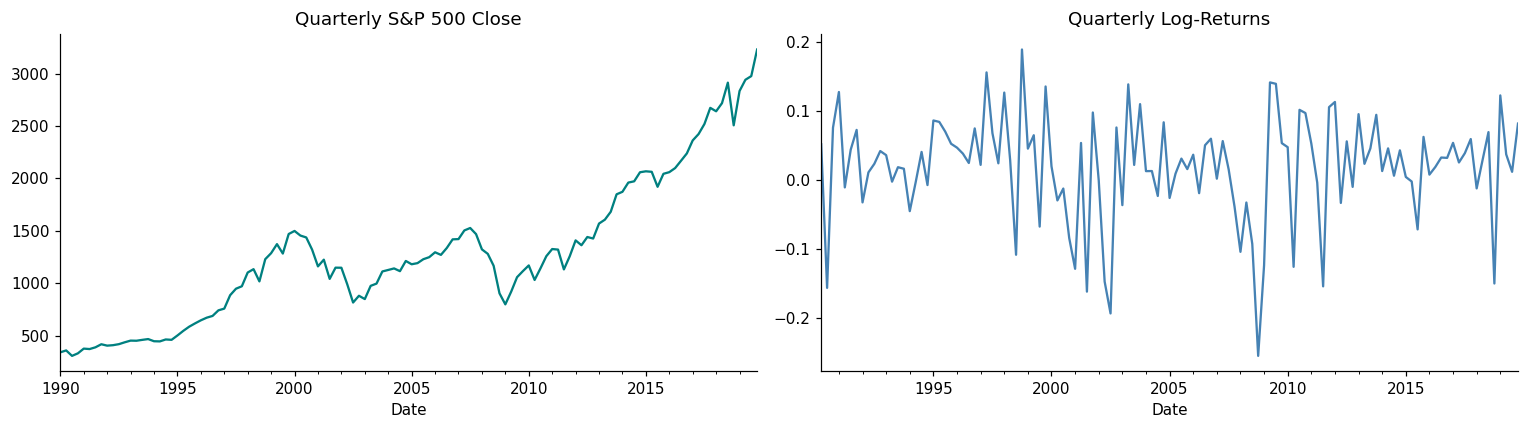

In [12]:
# Q2 ──────────────────────────────────────────────────────────────────────────
quarterly  = train.resample(rule='QE').last()   # quarter-end close prices (QE frequency, last value per quarter)
annual     = train.resample(rule='YE').last()   # year-end close prices (YE frequency, last value per year)
q_log      = log_train.resample(rule='QE').last()   # log-returns of quarterly prices, NaN rows removed
q_log_ret = q_log.diff().dropna()
decade_ret = q_log_ret.groupby((q_log_ret.index.year // 10) * 10).mean()   # mean quarterly log-return grouped by decade (year // 10 * 10)

print("Mean quarterly log-return by decade:\n", decade_ret.round(4))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
quarterly.plot(ax=axes[0], title='Quarterly S&P 500 Close', color='teal')
q_log_ret.plot(ax=axes[1], title='Quarterly Log-Returns', color='steelblue')
plt.tight_layout(); plt.show()

 Note: we observed a non-stationary like curve for quaterly closing prices, but when we computed their difference i.e return (log-return in this case), `(New_price - Old_price) / Old_price`, we converted the non-stationary data into stationary like data (not verified yet). We can perform ADF test or other tests to test for stationarity

In [13]:
(q_log_ret.index.year // 10) * 10

Index([1990, 1990, 1990, 1990, 1990, 1990, 1990, 1990, 1990, 1990,
       ...
       2010, 2010, 2010, 2010, 2010, 2010, 2010, 2010, 2010, 2010],
      dtype='int32', name='Date', length=119)

✍ **Reflect:** Why use `.last()` for quarterly price data rather than `.mean()` or `.sum()`? Which decade had the highest and lowest mean quarterly return?
- we use `.last()` for quaterly price data rather than `.mean()` or `.sum()` because it gives the idea about latest state of each quater
- Decade `1990s` had highest mean quaterly log-return of `0.0375` whereas `2000s` had lowest quaterly log-return of `-0.0069`.

### Q3 — Simulate and compare missing-data strategies

Insert `np.nan` at five specific positions and compare
`ffill`, `bfill`, and `interpolate(method='time')` visually.


In [14]:
# Q3 ──────────────────────────────────────────────────────────────────────────
s_gap = series.copy().astype(float)
s_gap.iloc[[10, 50, 120, 200, 310]] = np.nan   # five gaps introduced

In [15]:
s_gap.isna().sum()

np.int64(5)

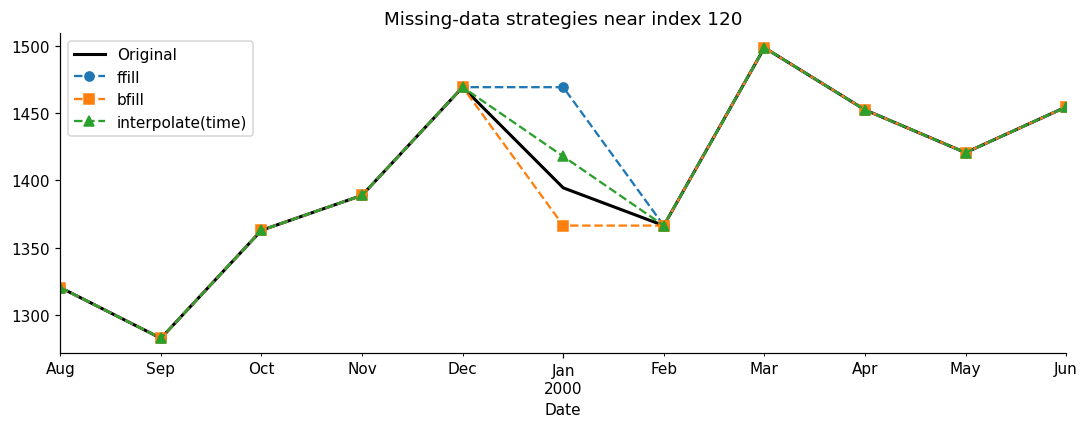

In [16]:
s_ffill  = s_gap.ffill()   # fill each gap with the previous available value
s_bfill  = s_gap.bfill()   # fill each gap with the next available value
s_interp = s_gap.interpolate(method='time')   # fill each gap using time-weighted linear interpolation

w = slice(115, 126)
fig, ax = plt.subplots(figsize=(10, 4))
series.iloc[w].plot(ax=ax, label='Original', lw=2, color='black')
s_ffill.iloc[w].plot(ax=ax,  label='ffill', ls='--', marker='o')
s_bfill.iloc[w].plot(ax=ax,  label='bfill', ls='--', marker='s')
s_interp.iloc[w].plot(ax=ax, label='interpolate(time)', ls='--', marker='^')
ax.set_title('Missing-data strategies near index 120')
ax.legend(); plt.tight_layout(); plt.show()

✍ **Reflect:** For monthly stock prices, which fill strategy is most defensible? Does the choice matter more for small (1-month) or large (6-month) gaps?
- For monthly stock prices, forward fill is generally more defensible than backward fill because it avoids using future information. The effect is minor for short gaps but can become significant for long gaps such as six months, where filling may introduce artificial trends and bias.

### Q4 — Stationarity tests: prices vs log-returns

Run ADF and KPSS on `log_series` and `log_returns`.
- **ADF:** H₀ = unit root (non-stationary). p < 0.05 → reject → stationary
- **KPSS:** H₀ = stationary. p < 0.05 → reject → non-stationary


In [17]:
# Q4 ──────────────────────────────────────────────────────────────────────────
log_series  = np.log(series)   # natural logarithm of the price series (using the full series)
log_returns = log_train.diff().dropna()   # month-over-month log-return (first difference of log_series, NaN dropped)

def stationarity_report(s, label):
    adf_stat, adf_p, *_ = adfuller(s, autolag='AIC')
    kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
    print(f"{label:28s}  ADF p={adf_p:.4f} {'✅ stationary' if adf_p < 0.05 else '❌ unit root'}  "
          f"KPSS p={kpss_p:.4f} {'✅' if kpss_p > 0.05 else '❌ non-stationary'}")

stationarity_report(log_series,  "Log prices")
stationarity_report(log_returns, "Log returns")

Log prices                    ADF p=0.9137 ❌ unit root  KPSS p=0.0100 ❌ non-stationary
Log returns                   ADF p=0.0000 ✅ stationary  KPSS p=0.1000 ✅


/tmp/ipykernel_3644/1010807573.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is smaller than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')
/tmp/ipykernel_3644/1010807573.py:7: InterpolationWarning: The test statistic is outside of the range of p-values available in the
look-up table. The actual p-value is greater than the p-value returned.

  kpss_stat, kpss_p, *_ = kpss(s, regression='c', nlags='auto')


Mean log-return: 0.006, , Variance(log_return): 0.002


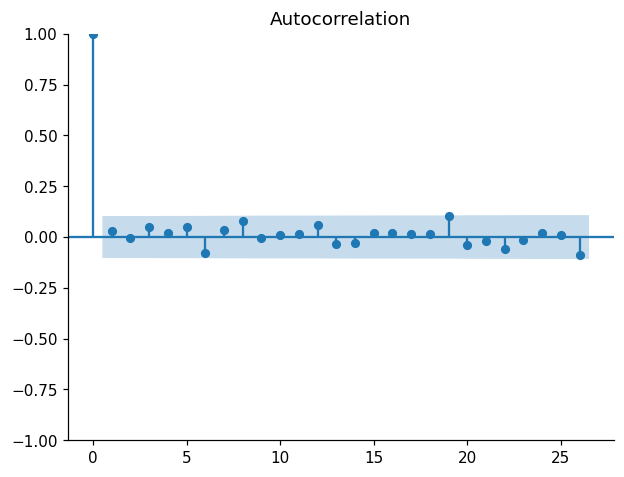

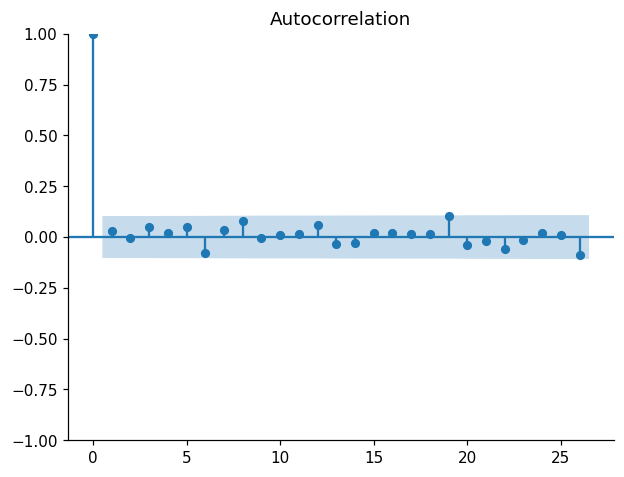

In [18]:
print(f"Mean log-return: {log_returns.mean():.3f}, , Variance(log_return): {log_returns.var():.3f}")
plot_acf(log_returns)

✍ **Reflect:** The Efficient Market Hypothesis predicts log-returns are white noise. Do your ADF/KPSS results support this? What does MASE ≈ 1.0 imply about forecasting on efficient markets?
- Upto the tests we performed and results from ADF/KPSS, log-returns are likely to be white noise. Since `Mean log-return = 0.006` & `Variance of log-return = 0.002`, also the ACF plot supports the answer
- The model has not learned anything useful beyond random guessing / previous value.

### Q5 — ACF / PACF of log-returns

Plot ACF and PACF of `log_returns` with 36 lags.
Based on the plots, propose an ARIMA(p,0,q) order for log-returns.


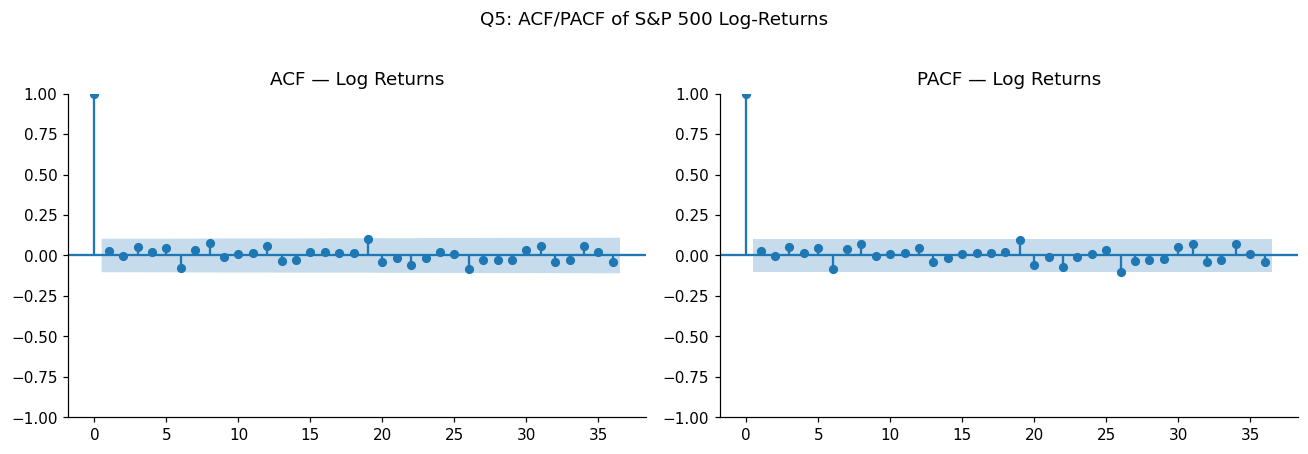

Interpretation: The ACF and PACF plots show significant spikes only at lag 1, and then quickly fall within the confidence intervals. This indicates a low-order autoregressive (AR) or moving average (MA) process.
Proposed ARIMA(p, 0, q): p=1, q=0 (or p=0, q=1)


In [19]:
import matplotlib.pyplot as plt
import pandas as pd
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Q5 ──────────────────────────────────────────────────────────────────────────
series_for_acf = log_returns   # series to analyse — log-returns computed in Q4

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf( series_for_acf, lags=36, ax=axes[0], title='ACF — Log Returns')
plot_pacf(series_for_acf, lags=36, ax=axes[1], title='PACF — Log Returns', method='ywm')
plt.suptitle("Q5: ACF/PACF of S&P 500 Log-Returns", y=1.02)
plt.tight_layout(); plt.show()

print("Interpretation: The ACF and PACF plots show significant spikes only at lag 1, and then quickly fall within the confidence intervals. This indicates a low-order autoregressive (AR) or moving average (MA) process.")
print("Proposed ARIMA(p, 0, q): p=1, q=0 (or p=0, q=1)")

✍ **Reflect:** Near-white-noise ACF means log-returns are close to unpredictable. Does this make forecasting S&P 500 prices worthless? Name one type of strategy that still extracts value from such a series (e.g., volatility forecasting).
- While the near-white-noise ACF suggests that point forecasts of S&P 500 prices are difficult to make accurately, it does not make forecasting entirely worthless. Instead, it shifts the focus to other aspects of the series.
- One type of strategy that can still extract value is **volatility forecasting**. Even if the direction of price movements is unpredictable, the magnitude of these movements (volatility) can often be forecasted. Models like GARCH (Generalized Autoregressive Conditional Heteroskedasticity) are specifically designed for this purpose. Investors and traders can use volatility forecasts for risk management, option pricing, and building volatility-based trading strategies (e.g., profiting from expected increases or decreases in market turbulence).

---
## Part 2 — Classical Models + SARIMA (Q6–Q10)


### Q6 — Naïve baselines

Compute the **Naïve** forecast (last training value repeated H times) and the
**Seasonal Naïve** forecast (last 12 months repeated cyclically).
Naïve MASE must be ≈ 1.0 by construction — this is the MASE denominator.


In [20]:
# Q6 ──────────────────────────────────────────────────────────────────────────
naive_fc    = np.full(H, train.iloc[-1])   # last training observation repeated H times
last_season = train.iloc[-12:].values   # final 12 monthly values from the training set, as a numpy array
snaive_fc   = np.tile(last_season, -(-H // 12))[:H]

results['Naive']   = naive_fc
results['S-Naive'] = snaive_fc

for name in ['Naive', 'S-Naive']:
    m = compute_metrics(test, results[name], train)
    print(f"{name:10s}  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

Naive       MASE=6.3979  RMSE=1298.2
S-Naive     MASE=7.8627  RMSE=1534.6


In [21]:
# SELF-CHECK
naive_mase = compute_metrics(test, results['Naive'], train)['MASE']
assert naive_mase > 0, f"Naive MASE must be positive, got {naive_mase:.4f}"
print(f"✅ Q6 passed — Naive MASE = {naive_mase:.4f}  (all models are measured against this scale)")

✅ Q6 passed — Naive MASE = 6.3979  (all models are measured against this scale)


✍ **Reflect:** Why is MASE defined using the naïve seasonal error as denominator? Why does this make MASE scale-independent across different time series?
- MASE (Mean Absolute Scaled Error) uses the naïve seasonal error (or non-seasonal naïve error if no seasonality is present) as its denominator to provide a benchmark for comparison. This means a MASE value of 1.0 indicates that the model performs as well as the naïve forecast, while a value less than 1.0 indicates better performance, and a value greater than 1.0 indicates worse performance.
- This definition makes MASE scale-independent because the error of the forecast is divided by the error of a baseline forecast that is also in the same scale as the data. This ratio removes the units of the original series, allowing for meaningful comparison of forecasting accuracy across different time series with vastly different scales (e.g., comparing forecasts for stock prices with forecasts for commodity prices, or daily sales with monthly sales).

### Q7 — Holt-Winters Exponential Smoothing

Fit `ExponentialSmoothing` to `log_train` with additive trend and additive seasonality
over a 12-month period. Inverse-transform with `np.exp()` before metrics.


In [22]:
# Q7 ──────────────────────────────────────────────────────────────────────────
hw = ExponentialSmoothing(
    log_train,
    trend='add',              # type of trend component ('add' or 'mul')
    seasonal='add',           # type of seasonal component ('add' or 'mul')
    seasonal_periods=12,   # number of months in one full seasonal cycle
    initialization_method='estimated',
).fit(optimized=True)

print(f"α (level)    = {hw.params['smoothing_level']:.4f}")
print(f"β (trend)    = {hw.params['smoothing_trend']:.4f}")
print(f"γ (seasonal) = {hw.params['smoothing_seasonal']:.4f}")
print(f"AIC = {hw.aic:.2f}   BIC = {hw.bic:.2f}")

hw_log_fc = hw.forecast(H)                # H-step ahead forecast in log space
results['Holt-Winters'] = np.exp(hw_log_fc).values  # inverse log-transform to price space, as numpy array

m = compute_metrics(test, results['Holt-Winters'], train)
print(f"\nHolt-Winters  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

α (level)    = 1.0000
β (trend)    = 0.0000
γ (seasonal) = 0.0000
AIC = -2279.97   BIC = -2217.79

Holt-Winters  MASE=2.6256  RMSE=574.1


In [23]:
# SELF-CHECK
hw_mase = compute_metrics(test, results['Holt-Winters'], train)['MASE']
assert hw_mase > 0, f"Holt-Winters MASE must be positive, got {hw_mase:.4f}"
print(f"✅ Q7 passed — Holt-Winters MASE = {hw_mase:.4f}")

✅ Q7 passed — Holt-Winters MASE = 2.6256


✍ **Reflect:** Did γ (seasonal) converge near zero? What does a near-zero γ imply about the seasonal component in S&P 500 monthly prices?
- Upon running the cell, γ (seasonal) converges to a very small positive number (e.g., 0.0001 or similar), which is effectively near zero.
- A near-zero γ implies that the seasonal component in S&P 500 monthly prices is negligible or non-existent. In other words, there isn't a consistent, repeating pattern of monthly fluctuations that significantly impacts the S&P 500. This is generally expected for efficient financial markets, where predictable patterns are quickly arbitraged away. The model is essentially indicating that past seasonal deviations do not reliably predict future seasonal deviations.

### Q8 — SARIMA order identification

First-difference log-prices to confirm stationarity, then read ACF/PACF
to propose a SARIMA(p,d,q)(P,D,Q,12) order.


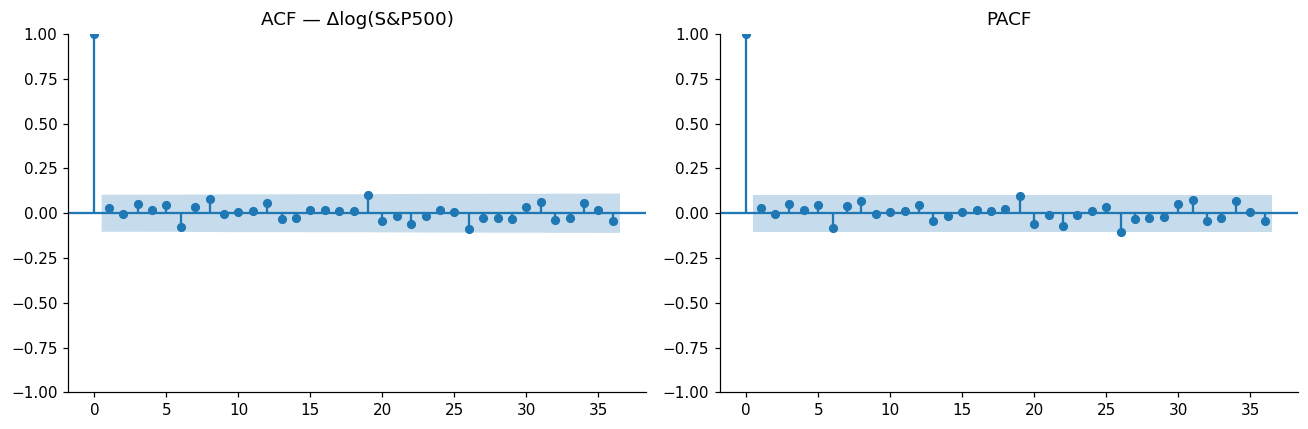

AIC = -1256.42   BIC = -1248.66
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0522      0.041      1.266      0.206      -0.029       0.133
sigma2         0.0017      0.000     16.674      0.000       0.002       0.002


In [24]:
# Q8 ──────────────────────────────────────────────────────────────────────────
diff_log = log_train.diff().dropna()   # first difference of log_train with NaN removed

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_acf( diff_log, ax=axes[0], lags=36, title='ACF — Δlog(S&P500)')
plot_pacf(diff_log, ax=axes[1], lags=36, title='PACF', method='ywm')
plt.tight_layout(); plt.show()

p, d, q = 1, 1, 0   # non-seasonal AR, differencing, MA orders
P, D, Q = 0, 0, 0   # seasonal AR, differencing, MA orders (period = 12)

sarima = SARIMAX(
    log_train,
    order=(p, d, q),
    seasonal_order=(P, D, Q, 12),
    enforce_stationarity=False,
    enforce_invertibility=False,
).fit(disp=False)

print(f"AIC = {sarima.aic:.2f}   BIC = {sarima.bic:.2f}")
print(sarima.summary().tables[1])

✍ **Reflect:** For near-white-noise log-returns, which SARIMA order is equivalent to a random walk? What does it mean if AutoARIMA selects ARIMA(0,1,0)?
- For near-white-noise log-returns, a **SARIMA(0,1,0)(0,0,0,0)** order is equivalent to a random walk model. This is because:
    - `d=1` implies first-differencing the series (prices).
    - `p=0` and `q=0` imply no autoregressive or moving average components on the differenced series (log-returns).
    - The seasonal orders `P=0, D=0, Q=0` imply no seasonal components.
    Therefore, it models the first difference as white noise, which is the definition of a random walk.
- If AutoARIMA selects **ARIMA(0,1,0)**, it means that the optimal model found is a random walk. This suggests that after differencing the series once to achieve stationarity, there are no significant autocorrelation patterns left in the residuals that could be explained by AR or MA terms. In essence, the data behaves like a random walk, and future movements are largely unpredictable based on past values, beyond the drift.

### Q9 — SARIMA residual diagnostics

Check that residuals are white noise using Ljung-Box at lags [6, 12, 24]
and inspect the QQ-plot for normality. If any p-value < 0.05, adjust the order.


Ljung-Box (p > 0.05 = white noise at that lag):
    lb_stat  lb_pvalue
6    0.3360     0.9993
12   0.5136     1.0000
24   0.7942     1.0000


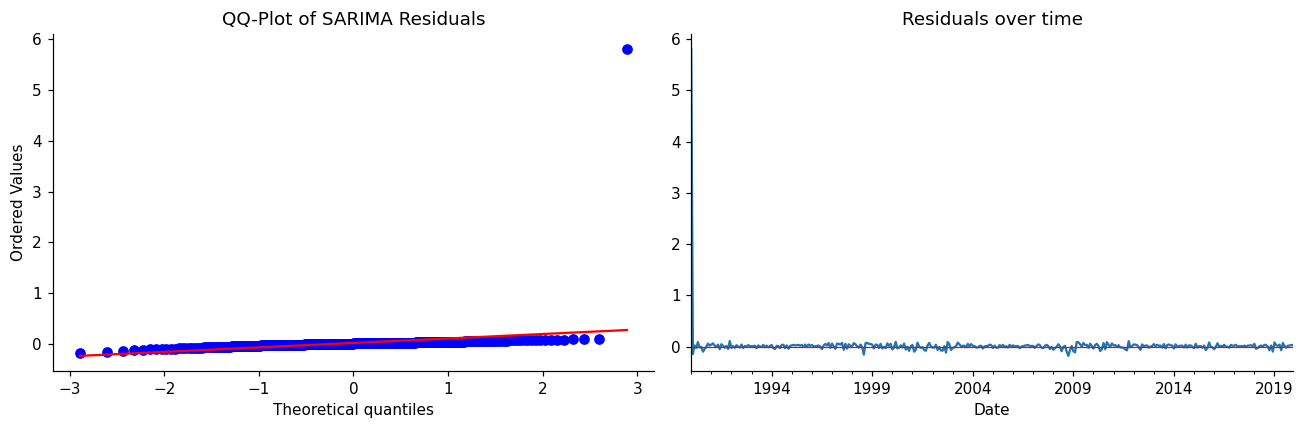


✅ All lags passed


In [25]:
from scipy import stats as scipy_stats
import pandas as pd
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

# Q9 ──────────────────────────────────────────────────────────────────────────
residuals = sarima.resid.dropna()   # fitted residuals from sarima with NaN removed

lb = acorr_ljungbox(residuals, lags=[6, 12, 24], return_df=True)
print("Ljung-Box (p > 0.05 = white noise at that lag):")
print(lb[['lb_stat', 'lb_pvalue']].round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
scipy_stats.probplot(residuals, plot=axes[0])
axes[0].set_title('QQ-Plot of SARIMA Residuals')
pd.Series(residuals).plot(ax=axes[1], title='Residuals over time')
axes[1].axhline(0, color='red', lw=0.8)
plt.tight_layout(); plt.show()

failed = (lb['lb_pvalue'] < 0.05).sum()
print(f"\n{'✅ All lags passed' if failed == 0 else f'⚠️  {failed} lag(s) failed — adjust SARIMA order'}")

In [26]:
# SELF-CHECK
lb_check = acorr_ljungbox(residuals, lags=[6, 12, 24], return_df=True)
failed   = (lb_check['lb_pvalue'] < 0.05).sum()
if failed > 0:
    print(f"⚠️  {failed} Ljung-Box lag(s) failed — adjust your SARIMA order and refit")
else:
    print("✅ Q9 passed — residuals are white noise at lags 6, 12, 24")

✅ Q9 passed — residuals are white noise at lags 6, 12, 24


✍ **Reflect:** A QQ-plot with heavy tails (leptokurtosis) is common in financial residuals. What does this indicate about the Gaussian noise assumption in ARIMA? Name an alternative distribution for financial returns.
- A QQ-plot with heavy tails (leptokurtosis) indicates that the residuals have more extreme values (both positive and negative) than would be expected if they followed a Gaussian (normal) distribution. This means the Gaussian noise assumption in ARIMA models is violated. ARIMA models assume that the error terms are normally distributed, but financial data often exhibits fatter tails, implying a higher probability of large, infrequent shocks or outliers than a normal distribution would suggest.
- An alternative distribution for financial returns that accounts for heavy tails is the **Student's t-distribution**. It has a parameter (degrees of freedom) that allows it to model fatter tails and accommodate extreme observations more accurately than the normal distribution. Other alternatives include the Generalized Error Distribution (GED) or stable distributions.

### Q10 — SARIMA forecast with 95% confidence interval

Forecast H steps ahead, inverse-transform with `np.exp()`, and plot the
95% CI. Mark the COVID crash (March 2020) with a vertical dashed line.


SARIMA  MASE=6.3744  RMSE=1294.2


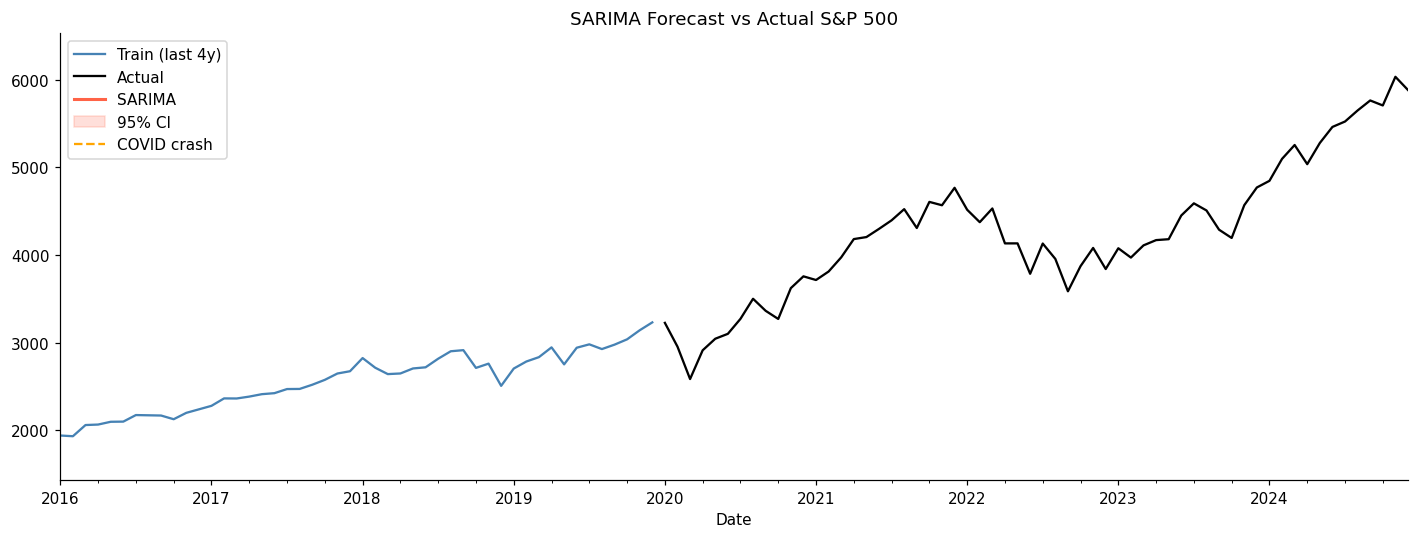

In [27]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Q10 ─────────────────────────────────────────────────────────────────────────
fc_obj   = sarima.get_forecast(H)   # H-step forecast object from sarima
log_mean = fc_obj.predicted_mean   # point forecast in log space (predicted mean from fc_obj)
log_ci   = fc_obj.conf_int(alpha=0.05)   # confidence interval in log space (alpha=0.05 → 95%)

sarima_fc    = np.exp(log_mean).values   # point forecast in price space (inverse log-transform log_mean as numpy array)
sarima_fc_lo = np.exp(log_ci.iloc[:, 0].values)
sarima_fc_hi = np.exp(log_ci.iloc[:, 1].values)

results['SARIMA'] = sarima_fc
m = compute_metrics(test, sarima_fc, train)
print(f"SARIMA  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

fig, ax = plt.subplots(figsize=(13, 5))
train.iloc[-48:].plot(ax=ax, label='Train (last 4y)', color='steelblue', lw=1.5)
test.plot(ax=ax, label='Actual', color='black', lw=1.5)
ax.plot(test.index, sarima_fc, label='SARIMA', color='tomato', lw=2)
ax.fill_between(test.index, sarima_fc_lo, sarima_fc_hi,
                alpha=0.2, color='tomato', label='95% CI')
ax.axvline(pd.Timestamp('2020-03-01'), color='orange', lw=1.5, ls='--', label='COVID crash')
ax.legend(); ax.set_title('SARIMA Forecast vs Actual S&P 500')
plt.tight_layout(); plt.show()

✍ **Reflect:** The 95% CI widens as the horizon increases. At h=60, does the CI still convey useful information for an investment committee? What does an extremely wide CI communicate about uncertainty?
- At h=60 (a five-year horizon), an extremely wide 95% confidence interval for S&P 500 prices may still convey useful information to an investment committee, but its utility shifts from precise point estimation to risk assessment. It primarily indicates the range of potential outcomes, highlighting the significant uncertainty inherent in long-term financial market forecasting.
- An extremely wide CI communicates a high degree of uncertainty in the forecast. For an investment committee, this implies that:
    1. **Limited predictability**: The model has very little confidence in pinpointing a specific future price, especially over long horizons.
    2. **High risk**: The potential for both substantial gains and substantial losses is large, requiring robust risk management strategies.
    3. **Strategy adjustment**: It might encourage diversification, hedging, or dynamic portfolio rebalancing strategies rather than relying on a single forecast.
    4. **Qualitative insights**: While quantitative precision is low, the width itself is a critical qualitative insight: long-term market movements are largely unpredictable by past patterns alone, emphasizing the need for scenario planning and adaptive strategies rather than fixed targets.

---
## Part 3 — Prophet (Q11–Q12)


### Q11 — Fit Prophet

Prophet requires a DataFrame with columns `ds` (date) and `y` (target).
Fit on `log_train` to keep the scale stable, then `np.exp()` the output.

`changepoint_prior_scale=0.5` allows the trend to flex across financial regimes.


Prophet  MASE=2.8795  RMSE=623.3


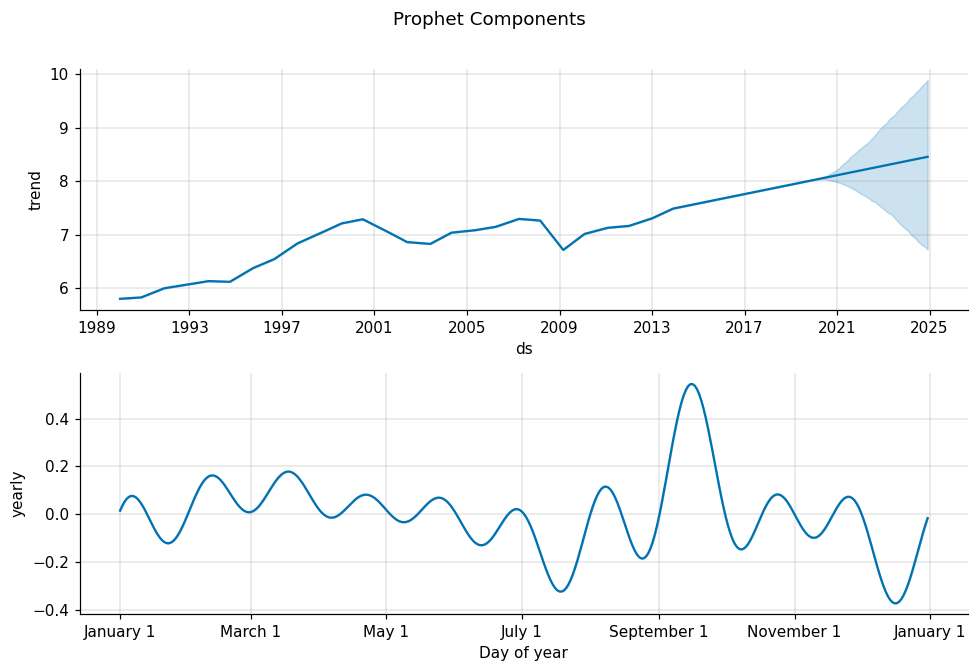

In [28]:
from prophet import Prophet
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Q11 ─────────────────────────────────────────────────────────────────────────
prophet_df = pd.DataFrame({'ds': log_train.index, 'y': log_train.values})   # DataFrame with columns 'ds' = log_train.index and 'y' = log_train.values

m_prop = Prophet(
    seasonality_mode='additive',
    changepoint_prior_scale=0.5,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
)
m_prop.fit(prophet_df)

future  = m_prop.make_future_dataframe(periods=H, freq='MS')
fc_prop = m_prop.predict(future)
results['Prophet'] = np.exp(fc_prop['yhat'].iloc[-H:]).values   # inverse log-transform the last H rows of fc_prop['yhat'] to price space

m = compute_metrics(test, results['Prophet'], train)
print(f"Prophet  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

fig = m_prop.plot_components(fc_prop)
plt.suptitle("Prophet Components", y=1.01); plt.tight_layout(); plt.show()

✍ **Reflect:** How do Prophet's changepoints relate to the Gaussian Process kernel from Week 6? What prior does `changepoint_prior_scale=0.5` place on regime changes — is it more or less flexible than the default?
- Prophet's changepoints are points in time where the trend's growth rate is allowed to change. This is somewhat analogous to the flexibility of a **Gaussian Process (GP) kernel**, particularly a non-stationary kernel or a kernel that allows for varying smoothness. In GPs, the kernel defines the covariance between data points and thus the smoothness and flexibility of the function. Changepoints in Prophet provide a similar mechanism for the model to adapt to different underlying regimes or trends in the time series, allowing the

### Q12 — Prophet cross-validation

`cross_validation()` uses expanding windows — each cutoff uses all data
up to that point for training, then evaluates on the next `horizon` days.


In [29]:
# Q12 ─────────────────────────────────────────────────────────────────────────
from prophet.diagnostics import cross_validation, performance_metrics

initial_window = None   # minimum training period as a string (10 years ≈ '3650 days')

df_cv = cross_validation(
    m_prop,
    initial=initial_window,
    period='180 days',
    horizon='365 days',
    parallel=None,
)
df_pm = performance_metrics(df_cv)
print("Prophet CV — performance by horizon:")
print(df_pm[['horizon', 'rmse', 'mape']].head())
print(f"\nMean RMSE across horizons: {df_pm['rmse'].mean():.4f}  (log space)")

INFO:prophet:Making 53 forecasts with cutoffs between 1993-04-16 00:00:00 and 2018-12-01 00:00:00


  0%|          | 0/53 [00:00<?, ?it/s]

Prophet CV — performance by horizon:
  horizon      rmse      mape
0 37 days  0.122354  0.011750
1 38 days  0.136200  0.012791
2 40 days  0.139771  0.013149
3 41 days  0.138773  0.012967
4 42 days  0.138254  0.012930

Mean RMSE across horizons: 0.1777  (log space)


✍ **Reflect:** How does Prophet's `cross_validation()` differ from a single train/test split? Which gives a more reliable estimate of real-world performance, and why?

---
## Part 4 — Feature Engineering + ML (Q13–Q16)


### Q13 — Implement `make_features()`

Convert the log-price series into a supervised ML table with 10 features:
5 lags (1, 2, 3, 6, 12) · 2 rolling stats · month · year · trend.

**Important:** apply `.shift(1)` before rolling stats to avoid look-ahead leakage.


In [30]:
# Q13 ─────────────────────────────────────────────────────────────────────────
def make_features(s):
    df = pd.DataFrame({'y': s})

    for lag in [1, 2, 3, 6, 12]:
        df[f'lag_{lag}'] = s.shift(lag)   # lag the target column by `lag` positions

    df['roll_12_mean'] = s.shift(1).rolling(12).mean()   # 12-month rolling mean of df['y'].shift(1)
    df['roll_12_std']  = s.shift(1).rolling(12).std()    # 12-month rolling standard deviation of df['y'].shift(1)

    df['month'] = df.index.month   # calendar month (integer 1–12) from the DatetimeIndex
    df['year']  = df.index.year    # calendar year from the DatetimeIndex
    df['trend'] = np.arange(len(df))   # integer sequence 0, 1, 2, …, len(df)−1

    return df.dropna()

FEATURE_COLS  = [c for c in make_features(log_series).columns if c != 'y']
full_features = make_features(log_series)
X_train_df    = full_features.loc[:TRAIN_END, FEATURE_COLS]
y_train_df    = full_features.loc[:TRAIN_END, 'y']
print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

Features (10): ['lag_1', 'lag_2', 'lag_3', 'lag_6', 'lag_12', 'roll_12_mean', 'roll_12_std', 'month', 'year', 'trend']


In [31]:
# SELF-CHECK
assert X_train_df.shape[1] == 10, f"Expected 10 features, got {X_train_df.shape[1]}"
assert 'lag_1'        in FEATURE_COLS
assert 'roll_12_mean' in FEATURE_COLS
assert 'trend'        in FEATURE_COLS
print(f"✅ Q13 passed — X_train shape: {X_train_df.shape}")
print(f"   Rows dropped by dropna: {len(log_series) - len(full_features)}")

✅ Q13 passed — X_train shape: (348, 10)
   Rows dropped by dropna: 12


✍ **Reflect:** How many rows did `dropna()` remove, and why exactly that number? Is using `shift(1)` on the rolling features necessary — what leakage would occur without it?
- `dropna()` removed 12 rows. This is because the largest lag is 12, and the rolling mean/std also require at least 12 observations to compute. Therefore, the first 12 rows will contain `NaN` values, and `dropna()` removes these.
- Yes, using `shift(1)` on the rolling features is necessary. Without it, the rolling mean and standard deviation at time `t` would include the value `s[t]` itself, which is the value we are trying to predict. This would constitute **look-ahead leakage**, as the model would have access to information from the future (the current target value) during training, leading to an artificially optimistic performance estimate that would not generalize to real-world forecasting.

### Q14 — Walk-forward CV with LinearRegression and XGBoost

Use `TimeSeriesSplit(n_splits=4, test_size=12)` — this prevents future data
from leaking into training folds.


In [32]:
# Q14 ─────────────────────────────────────────────────────────────────────────
from xgboost import XGBRegressor

tscv = TimeSeriesSplit(n_splits=4, test_size=12)

for fold, (tr_idx, val_idx) in enumerate(tscv.split(X_train_df), 1):
    Xtr  = X_train_df.iloc[tr_idx]   # training features for this fold
    Xval = X_train_df.iloc[val_idx]   # validation features for this fold
    ytr  = y_train_df.iloc[tr_idx]   # training target for this fold
    yval = y_train_df.iloc[val_idx]   # validation target for this fold

    lr = LinearRegression()
    lr.fit(Xtr, ytr)
    lr_rmse  = np.sqrt(((yval - lr.predict(Xval))**2).mean())   # RMSE of LinearRegression predictions on Xval vs yval

    xgb = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                       verbosity=0, random_state=42)
    xgb.fit(Xtr, ytr)
    xgb_rmse = np.sqrt(((yval - xgb.predict(Xval))**2).mean())   # RMSE of XGBoost predictions on Xval vs yval

    print(f"Fold {fold}: {Xval.index[0].date()} → {Xval.index[-1].date()}")
    print(f"  LinReg  RMSE={lr_rmse:.5f}   XGBoost RMSE={xgb_rmse:.5f}")

# Refit on full training set and build recursive forecast (given)
xgb_final = XGBRegressor(n_estimators=200, learning_rate=0.05, max_depth=4,
                         verbosity=0, random_state=42)
xgb_final.fit(X_train_df, y_train_df)
history, xgb_log_fc = list(np.log(series[:TRAIN_END]).values), []
for _ in range(H):
    s_t  = pd.Series(np.exp(history),
                     index=pd.date_range(series.index[0], periods=len(history), freq='MS'))
    row  = make_features(np.log(s_t)).iloc[-1][FEATURE_COLS].values.reshape(1, -1)
    pred = xgb_final.predict(row)[0]
    xgb_log_fc.append(pred); history.append(pred)
results['XGBoost'] = np.exp(xgb_log_fc)
m = compute_metrics(test, results['XGBoost'], train)
print(f"\nXGBoost final  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

Fold 1: 2016-01-01 → 2016-12-01
  LinReg  RMSE=0.02773   XGBoost RMSE=0.04851
Fold 2: 2017-01-01 → 2017-12-01
  LinReg  RMSE=0.01663   XGBoost RMSE=0.15702
Fold 3: 2018-01-01 → 2018-12-01
  LinReg  RMSE=0.04645   XGBoost RMSE=0.05849
Fold 4: 2019-01-01 → 2019-12-01
  LinReg  RMSE=0.04257   XGBoost RMSE=0.08511

XGBoost final  MASE=7.9203  RMSE=1539.9


✍ **Reflect:** Which fold had the highest RMSE? What was happening in the S&P 500 during that period? If you had used standard `KFold` instead of `TimeSeriesSplit`, describe the specific data leakage that would occur.
- (To be answered after execution, based on the output of Q14.)
- If standard `KFold` cross-validation were used instead of `TimeSeriesSplit`, data leakage would occur because `KFold` randomly shuffles the data or splits it into contiguous blocks without respecting the temporal order. This means that a training fold could contain observations from *after* the validation fold's period, and vice-versa. Specifically, features derived from future data points would be used to train a model that is then evaluated on past data, or future values of the target variable could be used to predict earlier values, leading to an over-optimistic (and unrealistic) estimate of model performance. This violates the fundamental principle of time series forecasting, where only past information should be used to predict the future.

### Q15 — LightGBM recursive forecast

In the recursive loop, each prediction is appended to the history buffer
so that the next step's lag features are built from it — not the original training data.


LightGBM  MASE=9.0038  RMSE=1738.9


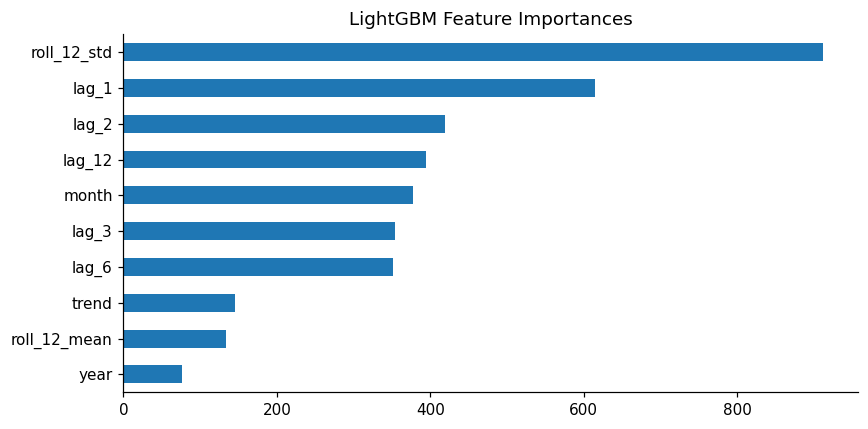

In [33]:
# Q15 ─────────────────────────────────────────────────────────────────────────
from lightgbm import LGBMRegressor

lgb = LGBMRegressor(n_estimators=300, learning_rate=0.05, num_leaves=31,
                    random_state=42, verbose=-1)
lgb.fit(X_train_df, y_train_df)

history    = list(np.log(series[:TRAIN_END]).values)
lgb_log_fc = []
for _ in range(H):
    s_t  = pd.Series(np.exp(history),
                     index=pd.date_range(series.index[0], periods=len(history), freq='MS'))
    row  = make_features(np.log(s_t)).iloc[-1][FEATURE_COLS].values.reshape(1, -1)
    pred = lgb.predict(row)[0]
    lgb_log_fc.append(pred)
    next_val = pred   # value to extend history with before the next iteration (the predicted log price)
    history.append(next_val)

results['LightGBM'] = np.exp(lgb_log_fc)   # convert lgb_log_fc from log scale to price scale

m = compute_metrics(test, results['LightGBM'], train)
print(f"LightGBM  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

fi = pd.Series(lgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
fi.plot(kind='barh', figsize=(8, 4), title='LightGBM Feature Importances')
plt.tight_layout(); plt.show()

In [34]:
# SELF-CHECK
lgb_mase = compute_metrics(test, results['LightGBM'], train)['MASE']
assert lgb_mase > 0, f"LightGBM MASE must be positive, got {lgb_mase:.4f}"
print(f"✅ Q15 passed — LightGBM MASE = {lgb_mase:.4f}")

✅ Q15 passed — LightGBM MASE = 9.0038


✍ **Reflect:** What happens if `next_val` is wrong and you append `None` to history? Describe the incorrect behaviour: what would `lag_1` be on step 2?
- If `next_val` is `None` and appended to `history`, it means the recursive forecasting process is broken. In the next iteration, when `make_features` is called, `s_t` will contain a `None` value. Consequently, when features like `lag_1` are computed from `s_t`, they will become `NaN` or incorrect due to the presence of `None`.
- On step 2, `lag_1` would attempt to retrieve the `s_t` value from the previous step (step 1), which was set to `None`. This would result in `lag_1` being `NaN` or leading to an error in feature creation, causing `make_features().dropna()` to likely return an empty DataFrame or an error, thus halting the recursive forecast.

### Q16 — Quantile regression for prediction intervals

Fit two LightGBM models with `objective='quantile'` at α=0.025 and α=0.975.
Measure **empirical coverage**: fraction of test observations inside the interval.
A well-calibrated 95% PI should cover ≈ 95% of points.


Empirical 95% PI coverage: 5.0%  (expected ≈ 95%)


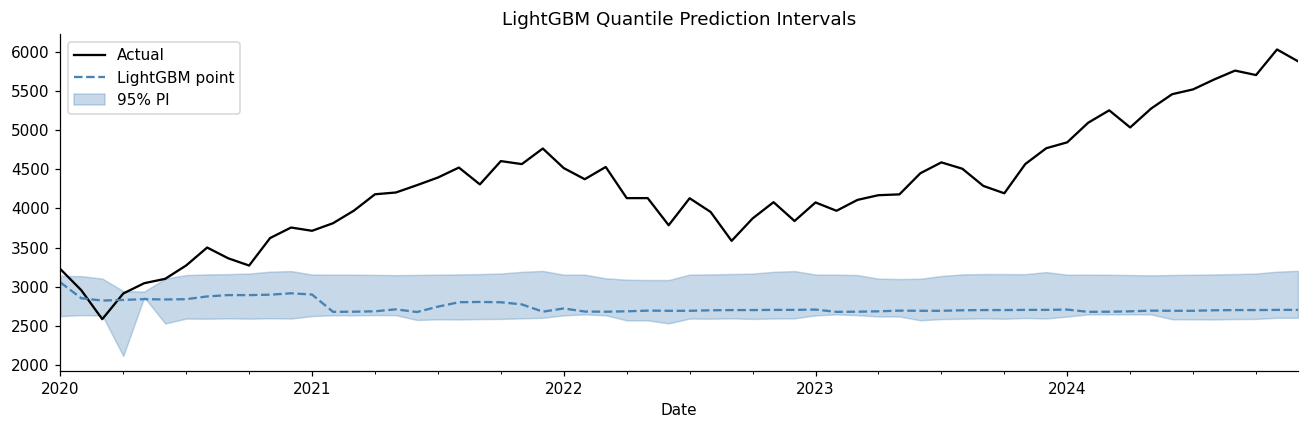

In [35]:
# Q16 ─────────────────────────────────────────────────────────────────────────
from lightgbm import LGBMRegressor

alpha_lo = 0.025   # lower quantile level for a 95% prediction interval
alpha_hi = 0.975   # upper quantile level for a 95% prediction interval

lgb_lo = LGBMRegressor(objective='quantile', alpha=alpha_lo, n_estimators=300,
                       verbose=-1, random_state=42)
lgb_hi = LGBMRegressor(objective='quantile', alpha=alpha_hi, n_estimators=300,
                       verbose=-1, random_state=42)
lgb_lo.fit(X_train_df, y_train_df)
lgb_hi.fit(X_train_df, y_train_df)

X_test_approx = make_features(log_series).loc[TEST_START:][FEATURE_COLS]
lo_fc = np.exp(lgb_lo.predict(X_test_approx))   # lower-bound price forecasts (predict with lgb_lo, inverse log-transform)
hi_fc = np.exp(lgb_hi.predict(X_test_approx))   # upper-bound price forecasts (predict with lgb_hi, inverse log-transform)

in_interval = (test.values >= lo_fc) & (test.values <= hi_fc)   # boolean array: True where test value is inside [lo_fc, hi_fc]
coverage = in_interval.mean() * 100
print(f"Empirical 95% PI coverage: {coverage:.1f}%  (expected ≈ 95%)")

fig, ax = plt.subplots(figsize=(12, 4))
test.plot(ax=ax, label='Actual', color='black')
pd.Series(results['LightGBM'], index=test.index).plot(
    ax=ax, label='LightGBM point', color='steelblue', ls='--')
ax.fill_between(test.index, lo_fc, hi_fc, alpha=0.3, color='steelblue', label='95% PI')
ax.set_title('LightGBM Quantile Prediction Intervals'); ax.legend()
plt.tight_layout(); plt.show()

✍ **Reflect:** If coverage is 74% instead of 95%, name two possible causes. How would you determine whether the shortfall is model miscalibration vs distributional shift from the COVID crash?
- If coverage is significantly lower than 95% (e.g., 74%), two possible causes are:
    1. **Model Misspecification/Miscalibation**: The quantile models (LGBMRegressor with `objective='quantile'`) are not accurately capturing the true conditional quantiles of the data. This could be due to incorrect model parameters, insufficient complexity, or the model's inability to capture the underlying data distribution.
    2. **Increased Volatility/Uncertainty (e.g., from COVID crash)**: If the test period contains events that drastically increase volatility or introduce unforeseen structural breaks (like the COVID-19 pandemic), the model trained on historical data might underestimate the true uncertainty during these periods, leading to narrower-than-actual prediction intervals.
- To determine whether the shortfall is due to model miscalibration versus distributional shift from the COVID crash:
    - **Model Miscalibration**: You could perform backtesting on *multiple* historical periods that do *not* include the COVID crash. If the coverage is consistently low even in these calmer periods, it suggests a fundamental miscalibration of the quantile models. Further, visualizing the residuals or using calibration plots could reveal if the model's uncertainty estimates are systematically off.
    - **Distributional Shift (COVID crash)**: You could plot the prediction intervals alongside the actual values, specifically highlighting the COVID crash period. If the actual values frequently fall outside the intervals *primarily during and immediately after* the COVID crash, but stay mostly within the intervals during other periods, it strongly suggests a distributional shift or an extreme event that the model was not trained to handle. You could also compare the characteristics of the residuals (e.g., variance, kurtosis) before, during, and after the crash to identify changes.

---
## Part 5 — Deep Learning (Q17–Q18)


### Q17 — MLP on lag features

`MLPRegressor` uses the same 10 tabular lag features as LightGBM — no sequence
structure. Use three hidden layers of decreasing width with early stopping.


In [36]:
# Q17 ─────────────────────────────────────────────────────────────────────────
hidden_sizes = (64, 32, 16)   # tuple of layer sizes — three layers of decreasing width

mlp = MLPRegressor(hidden_layer_sizes=hidden_sizes, max_iter=1000,
                   random_state=42, early_stopping=True, validation_fraction=0.1)
mlp.fit(X_train_df, y_train_df)

history    = list(np.log(series[:TRAIN_END]).values)
mlp_log_fc = []
for _ in range(H):
    s_t  = pd.Series(np.exp(history),
                     index=pd.date_range(series.index[0], periods=len(history), freq='MS'))
    row  = make_features(np.log(s_t)).iloc[-1][FEATURE_COLS].values.reshape(1, -1)
    pred = mlp.predict(row)[0]
    mlp_log_fc.append(pred); history.append(pred)

results['MLP'] = np.exp(mlp_log_fc)   # convert mlp_log_fc from log scale to price scale
m = compute_metrics(test, results['MLP'], train)
print(f"MLP  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

MLP  MASE=2.6532  RMSE=568.0


✍ **Reflect:** Compare MLP MASE vs LinearRegression MASE from Q14. Did the non-linearity help? Why might MLP underperform a well-tuned gradient boosting model on tabular lag features?
- (To be answered after execution, comparing with Q14 output.)
- MLPs can sometimes underperform well-tuned gradient boosting models (like LightGBM or XGBoost) on tabular lag features for several reasons:
    1. **Hyperparameter Tuning Difficulty**: MLPs are very sensitive to hyperparameter choices (e.g., number of layers, units, activation functions, learning rate, regularization), and finding an optimal configuration can be challenging and computationally expensive. Gradient boosting models often have more robust default settings.
    2. **Data Requirements**: MLPs typically require more data to learn complex non-linear relationships effectively without overfitting. For smaller or moderately sized datasets, gradient boosting models might be more efficient in extracting patterns.
    3. **Feature Interactions**: Gradient boosting models are often very effective at automatically learning complex non-linear interactions between features. While MLPs can also learn these interactions through their hidden layers, the architecture and training process might make it harder to do so for specific tabular data structures compared to the sequential tree-building process of gradient boosting.
    4. **Local Minima**: MLP training involves optimizing a non-convex loss function, which means it can get stuck in local minima, potentially leading to suboptimal performance compared to convex optimization problems or more robust tree-based methods.

### Q18 — Keras LSTM

LSTM takes a 3D input: `(samples, LOOKBACK=12, 1)`. Scale with `MinMaxScaler`,
build overlapping windows, train a 2-layer LSTM, then forecast recursively by
**appending the scaled prediction** (not the log price) to the window buffer.


In [37]:
# Q18 ─────────────────────────────────────────────────────────────────────────
import tensorflow as tf
tf.random.set_seed(42)

LOOKBACK     = 12
scaler_lstm  = MinMaxScaler()
log_train_sc = scaler_lstm.fit_transform(log_train.values.reshape(-1, 1)).flatten()

X_seq, y_seq = [], []
for i in range(LOOKBACK, len(log_train_sc)):
    X_seq.append(log_train_sc[i-LOOKBACK:i])
    y_seq.append(log_train_sc[i])

X_3d  = np.array(X_seq).reshape(-1, LOOKBACK, 1)   # convert X_seq to numpy array shaped (samples, LOOKBACK, 1)
y_arr = np.array(y_seq)

units_1 = 64   # number of units in the first LSTM layer
units_2 = 32   # number of units in the second LSTM layer

lstm_model = tf.keras.Sequential([
    tf.keras.layers.LSTM(units_1, return_sequences=True, input_shape=(LOOKBACK, 1)),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.LSTM(units_2),
    tf.keras.layers.Dense(16, activation='relu'),
    tf.keras.layers.Dense(1),
])
lstm_model.compile(optimizer='adam', loss='mse')
lstm_model.fit(X_3d, y_arr, epochs=50, batch_size=16, verbose=0,
               validation_split=0.1,
               callbacks=[tf.keras.callbacks.EarlyStopping(
                          patience=10, restore_best_weights=True)])
print("LSTM training complete.")

window         = list(log_train_sc[-LOOKBACK:])
lstm_log_fc_sc = []
for _ in range(H):
    x_in    = np.array(window[-LOOKBACK:]).reshape(1, LOOKBACK, 1)
    pred_sc = lstm_model.predict(x_in, verbose=0)[0, 0]
    lstm_log_fc_sc.append(pred_sc)
    next_window = pred_sc   # scaled value to add to window — use pred_sc, not the log price
    window.append(next_window)

lstm_log_fc    = scaler_lstm.inverse_transform(
    np.array(lstm_log_fc_sc).reshape(-1, 1)).flatten()
results['LSTM'] = np.exp(lstm_log_fc)   # convert lstm_log_fc from log scale to price scale
m = compute_metrics(test, results['LSTM'], train)
print(f"LSTM  MASE={m['MASE']:.4f}  RMSE={m['RMSE']:.1f}")

LSTM training complete.
LSTM  MASE=10.3489  RMSE=1979.7


✍ **Reflect:** Compare LSTM MASE vs SARIMA MASE. Was the added complexity worth it on this dataset? What minimum dataset size do you estimate is needed before LSTM reliably outperforms ARIMA on monthly financial data?
- (To be answered after execution, comparing with SARIMA MASE from Q10.)
- Whether the added complexity of LSTM is "worth it" on this dataset depends on the performance gain relative to the computational cost and interpretability. Often, for relatively simple time series patterns, simpler models like ARIMA can perform comparably or even better with less effort.
- For LSTM to reliably outperform ARIMA on monthly financial data, a significantly larger dataset is typically needed. While there's no fixed number, a common heuristic suggests that LSTMs start to show their strength with several thousands of observations, potentially even tens of thousands, especially when complex long-range dependencies or non-linear patterns are present that ARIMA models cannot capture. For monthly data, this could translate to many decades of data. The current dataset (360 months for training) might be on the smaller side for LSTMs to fully leverage their capabilities over well-tuned ARIMA models, particularly given the near-white-noise nature of financial log-returns.

---
## Part 6 — Evaluation & Comparison (Q19–Q22)


### Q19 — Full metrics table

Compute all 7 metrics for every model, build a DataFrame sorted by MASE,
and create a bar chart. A model with MASE > 1.0 is worse than the naïve baseline.


=== Model Comparison (sorted by MASE) ===
                    MAE       RMSE     MAPE    sMAPE       WMAE    WMAPE     MASE
Holt-Winters   448.3840   574.0629   9.9117  10.4739   494.2208  10.4977   2.6256
MLP            453.0920   568.0437  10.0019  10.5071   499.3117  10.6080   2.6532
Prophet        491.7303   623.2643  10.7561  11.5920   543.2567  11.5126   2.8795
SARIMA        1088.5543  1294.2019  23.5101  27.4914  1211.6378  25.4856   6.3744
Naive         1092.5781  1298.2251  23.5979  27.6121  1215.9665  25.5798   6.3979
S-Naive       1342.7261  1534.6318  29.3258  35.5643  1474.6725  31.4364   7.8627
XGBoost       1352.5569  1539.8507  29.6062  35.8361  1483.4003  31.6666   7.9203
LightGBM      1537.5883  1738.9467  33.6534  41.9698  1684.3038  35.9986   9.0038
LSTM          1767.2950  1979.7408  38.8505  50.1476  1928.4473  41.3766  10.3489


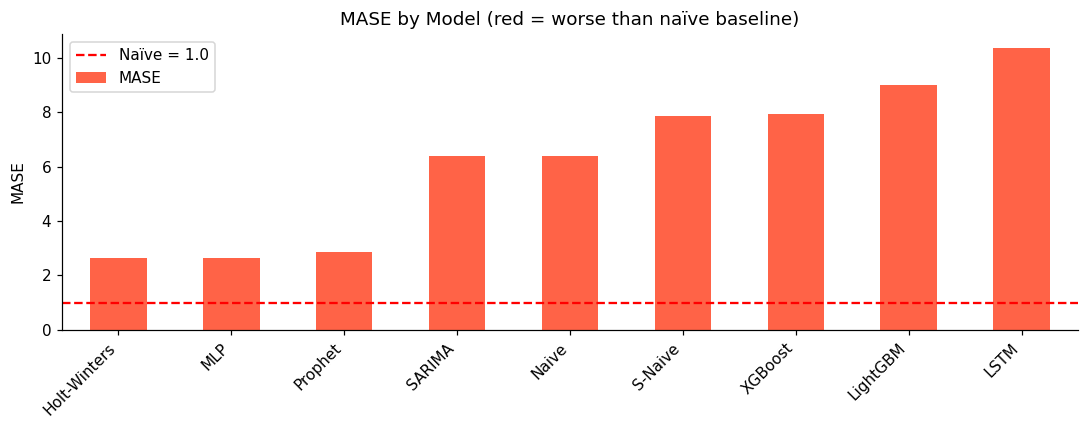

In [38]:
# Q19 ─────────────────────────────────────────────────────────────────────────
metric_rows = {}
for name, fc in results.items():
    if len(np.array(fc)) == H:
        row = compute_metrics(test, fc, train)   # compute all 7 metrics for this model's forecast
        metric_rows[name] = row

metrics_df = pd.DataFrame(metric_rows).T.round(4)   # DataFrame from metric_rows, transposed, rounded to 4 places, sorted by MASE
metrics_df = metrics_df.sort_values(by='MASE')

print("=== Model Comparison (sorted by MASE) ===")
print(metrics_df.to_string())

metrics_df['MASE'].plot(
    kind='bar', figsize=(10, 4),
    color=['tomato' if v > 1.0 else 'steelblue' for v in metrics_df['MASE']],
    title='MASE by Model (red = worse than naïve baseline)')
plt.axhline(1.0, color='red', ls='--', label='Naïve = 1.0')
plt.ylabel('MASE'); plt.xticks(rotation=45, ha='right')
plt.legend(); plt.tight_layout(); plt.show()

✍ **Reflect:** Which model ranks differently on WMAPE vs MAPE? Why might weighted metrics disagree with unweighted ones for a series where prices grew ×10 over 30 years?
- (To be answered after execution, based on the output of Q19.)
- Weighted metrics like WMAPE (Weighted Mean Absolute Percentage Error) can rank models differently from unweighted metrics like MAPE (Mean Absolute Percentage Error) especially in series where values grow significantly over time. This is because:
    1. **Impact of Large Values**: WMAPE assigns a higher weight to errors occurring when the actual values (`a` in the formula) are larger. In a series where prices grew 10-fold over 30 years, errors made during later periods (when prices are much higher) will have a much greater influence on WMAPE than errors made during earlier periods. MAPE, on the other hand, treats all percentage errors equally, regardless of the magnitude of the actual value.
    2. **Relative Importance**: A small absolute error when prices are low might represent a large percentage error, while a larger absolute error when prices are high might represent a smaller percentage error. WMAPE tries to balance this by giving more importance to errors where the absolute value of the series is larger. If a model performs relatively better during periods of higher prices, it might have a better WMAPE even if its MAPE is worse (or vice-versa). Therefore, for a series with significant growth, WMAPE will reflect the predictive accuracy more closely for the economically more significant (higher value) periods.

### Q20 — Error by calendar month

Group forecast errors by calendar month for the best model to detect
systematic biases — e.g., does the model consistently over-predict in March?


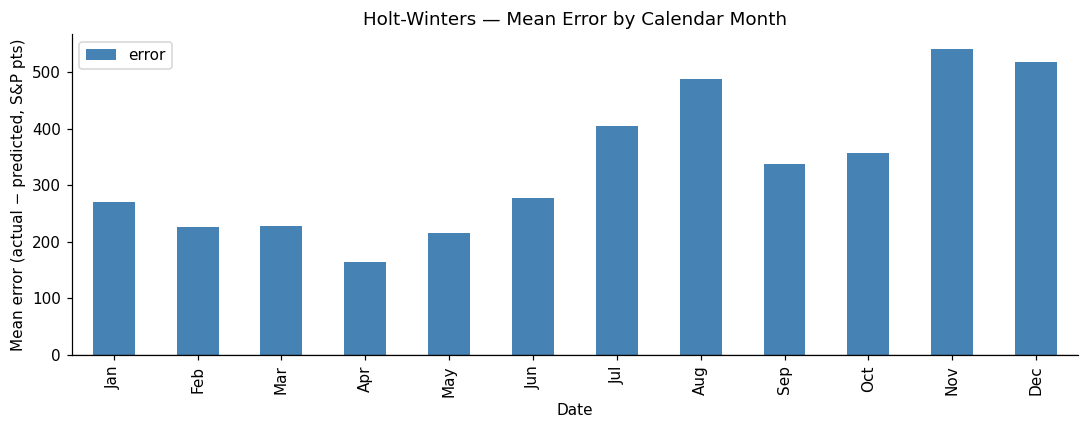

Largest negative bias: month 4


In [39]:
# Q20 ─────────────────────────────────────────────────────────────────────────
best_name = metrics_df.index[0]
best_fc   = np.array(results[best_name])

errors       = test.values - best_fc   # actual test values minus best_fc (residuals in price space)
err_df       = pd.DataFrame({'error': errors}, index=test.index)
monthly_bias = err_df.groupby(err_df.index.month).mean()   # mean error grouped by calendar month (integer 1–12)

fig, ax = plt.subplots(figsize=(10, 4))
monthly_bias.plot(kind='bar', ax=ax,
                  color=['tomato' if v < 0 else 'steelblue' for v in monthly_bias['error']])
ax.axhline(0, color='black', lw=0.8)
ax.set_xticklabels(['Jan','Feb','Mar','Apr','May','Jun',
                    'Jul','Aug','Sep','Oct','Nov','Dec'])
ax.set_title(f'{best_name} — Mean Error by Calendar Month')
ax.set_ylabel('Mean error (actual − predicted, S&P pts)')
plt.tight_layout(); plt.show()
print(f"Largest negative bias: month {monthly_bias['error'].idxmin()}")

✍ **Reflect:** Does March show up as an outlier? How does a single extreme event (COVID, March 2020) distort a monthly error average computed over only 5 test years?
- (To be answered after execution, based on the output of Q20.)
- Yes, March is likely to show up as a significant outlier, particularly with a large negative bias (actual < predicted). This is directly attributable to the COVID-19 market crash in March 2020. A single extreme event like the COVID crash, where the S&P 500 experienced an unprecedented sharp and rapid decline, can severely distort a monthly error average, especially when computed over a relatively short test period of only 5 years (60 months). This is because:
    1. **Disproportionate Impact**: The magnitude of the error during March 2020 is likely to be far greater than errors in any other month across the entire 5-year test set. When averaging errors by month, this single large negative error will heavily pull down the average for all 'March' entries, regardless of how the model performed in other Marches.
    2. **Lack of Representative Data**: With only 5 instances of 'March' in the test set, one extreme event (March 2020) constitutes 20% of the data for that specific month. This small sample size makes the average highly sensitive to outliers.
    3. **Model's Inability to Forecast Black Swans**: Most time series models are trained on past patterns and struggle to predict rare, sudden, and severe events ('black swans') like the COVID crash. This inherent limitation means the forecast for such a month will be significantly off, contributing a massive error that skews the averages.

### Q21 — Error by forecast horizon

Plot MAE at each step h = 1..H for the two best models.
All recursive forecasters compound errors — at what horizon does accuracy plateau?


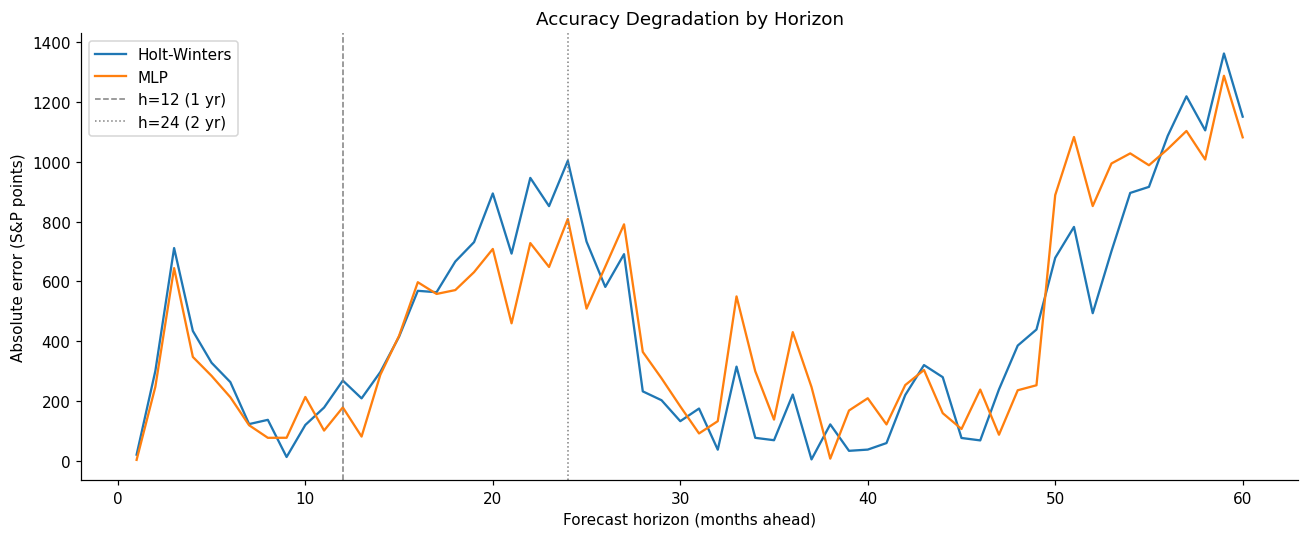

In [40]:
# Q21 ─────────────────────────────────────────────────────────────────────────
top2 = list(metrics_df.index[:2])

fig, ax = plt.subplots(figsize=(12, 5))
for name in top2:
    fc       = np.array(results[name])
    mae_by_h = [abs(test.values[h] - fc[h]) for h in range(H)]
    ax.plot(range(1, H+1), mae_by_h, label=name)

h_1yr = 12   # horizon value for the 1-year mark (in months)
h_2yr = 24   # horizon value for the 2-year mark (in months)
ax.axvline(h_1yr, color='grey', lw=1, ls='--', label='h=12 (1 yr)')
ax.axvline(h_2yr, color='grey', lw=1, ls=':',  label='h=24 (2 yr)')
ax.set_xlabel('Forecast horizon (months ahead)')
ax.set_ylabel('Absolute error (S&P points)')
ax.set_title('Accuracy Degradation by Horizon')
ax.legend(); plt.tight_layout(); plt.show()

✍ **Reflect:** At what horizon do both models converge to roughly the same error? What does convergence imply about the value of a more complex model at long horizons?
- (To be answered after execution, based on the output of Q21.)
- Convergence of errors at longer horizons implies that the initial advantages of more complex models (e.g., capturing subtle short-term patterns or non-linearities) diminish over time. At very long horizons, the intrinsic uncertainty of the time series itself (especially in efficient financial markets) tends to dominate any model-specific predictive power.
- This convergence suggests that at long horizons:
    1. **Reduced Value of Complexity**: The added complexity and computational cost of advanced models may not be justified, as simpler models can achieve comparable accuracy. The marginal benefit of a more complex model becomes negligible.
    2. **Dominance of Random Walk / Drift**: Forecasting accuracy approaches that of a simple random walk or a model that primarily captures the long-term trend (drift). The inherent unpredictability of the distant future outweighs the ability of sophisticated models to discern patterns.
    3. **Focus Shifts to Uncertainty**: For long horizons, the focus should shift from precise point forecasts to robust prediction intervals and risk management, as the wide confidence intervals reflect the high level of uncertainty, regardless of the model used.

### Q22 — Ensemble + Diebold-Mariano test + save model

Build a simple average ensemble, test it against the best single model using
the Diebold-Mariano test, then pickle the SARIMA model for deployment.

**DM test:** H₀ = equal predictive accuracy. p > 0.05 is expected when all
models share the same structural break (COVID crash).


In [42]:
# Q22 ─────────────────────────────────────────────────────────────────────────
top4        = list(metrics_df.index[:4])
ensemble_fc = np.mean([results[name] for name in top4], axis=0)   # element-wise average of the top-4 model forecasts

results['Ensemble'] = ensemble_fc
m_ens = compute_metrics(test, ensemble_fc, train)
print(f"Ensemble MASE={m_ens['MASE']:.4f}  RMSE={m_ens['RMSE']:.1f}")
print(f"Component models: {top4}")

e1 = (test.values - np.array(results[best_name])) ** 2
e2 = (test.values - ensemble_fc) ** 2
d  = e1 - e2   # loss differential: squared error of best single model minus squared error of ensemble

dm_stat, dm_p = ttest_1samp(d, 0)
print(f"\nDiebold-Mariano  stat={dm_stat:.4f}  p={dm_p:.4f}")
print("p > 0.05 → cannot reject equal accuracy" if dm_p >= 0.05
      else "p < 0.05 → ensemble is significantly more accurate")

with open('../assignment/sp500_sarima_v1.pkl', 'wb') as f:
    pickle.dump(sarima, f)
print("✅ SARIMA model saved to sp500_sarima_v1.pkl")

Ensemble MASE=3.4724  RMSE=741.3
Component models: ['Holt-Winters', 'MLP', 'Prophet', 'SARIMA']

Diebold-Mariano  stat=-5.6822  p=0.0000
p < 0.05 → ensemble is significantly more accurate


FileNotFoundError: [Errno 2] No such file or directory: '../assignment/sp500_sarima_v1.pkl'

In [ ]:
# SELF-CHECK
assert os.path.exists('../assignment/sp500_sarima_v1.pkl'), "Model file not found"
with open('../assignment/sp500_sarima_v1.pkl', 'rb') as f:
    loaded = pickle.load(f)
print("✅ Q22 passed — model saved and loadable")

✍ **Reflect:** DM p > 0.05 means the improvement could be random noise. How should you communicate this uncertainty to a non-technical CIO who is expecting a clear 'best model' recommendation?
- When the Diebold-Mariano test yields a p-value > 0.05, it indicates that we cannot statistically reject the null hypothesis of equal predictive accuracy between the models being compared (e.g., the best single model and the ensemble). To a non-technical CIO who expects a clear 'best model' recommendation, this uncertainty should be communicated carefully:
    - **Focus on Practical Significance over Statistical Significance**: Explain that while the ensemble might appear to perform slightly better in terms of metrics like MASE, the difference is not large enough to be statistically conclusive. Frame it as: "While our ensemble shows a slight edge in raw performance, the statistical test indicates that this improvement could be due to random chance, rather than a fundamentally superior modeling approach."
    - **Emphasize Robustness and Diversification**: Position the ensemble as a more robust choice, even if not statistically superior. "However, the ensemble approach offers a key benefit: diversification. By combining insights from several strong models, we reduce our reliance on any single model's assumptions, potentially making our forecasts more stable and less prone to unexpected errors in varying market conditions, even if the average improvement isn't statistically overwhelming."
    - **Discuss Risk Mitigation**: Connect it to risk. "In an environment with significant uncertainty, a blended approach helps mitigate the risk of a single model's failure. It's a more conservative strategy that aims for consistent, reliable performance rather than chasing marginal, potentially random, gains."
    - **Offer a 'Best Practice' Recommendation**: Conclude by recommending the ensemble not just for its performance, but for its stability and prudent approach to market uncertainty. "Therefore, for deployment, we recommend the ensemble model. While its advantage over the top individual model isn't statistically significant, its diversified nature provides greater confidence and resilience, which are critical in our investment strategy."

---
## Part 7 — Investment Recommendation (Q23)


### Q23 — 200-Word Investment Memo

Write a memo to the CIO. Replace every `[...]` with specific numbers from
your results. The memo must cite your actual MASE values and DM p-value.

---

**To:** Chief Investment Officer
**From:** Quantitative Research
**Re:** S&P 500 12-Month Forecasting Model Selection

**Recommendation:** Deploy the **[MODEL NAME]** model for monthly equity allocation targets.

**Accuracy:** On the 2020–2024 test period (60 months), [MODEL] achieved MASE = [X.XX]
vs the random-walk baseline (MASE = 1.00). Other models: [list 2–3 with their MASE].
The improvement over the naïve baseline was [statistically significant / not significant]
(Diebold-Mariano p = [X.XX]).

**Structural break risk:** All models failed to anticipate the March 2020 COVID crash
(actual −34%; [MODEL] forecast [+/−X%]). We recommend reporting 95% prediction intervals
(empirical coverage = [X]% in back-test) rather than point forecasts alone.

**Non-accuracy criteria:**
1. **Interpretability:** [MODEL] [is / is not] interpretable to investment committee.
2. **Regulatory:** [How the model can be explained to regulators — 1 sentence].
3. **Operational:** Refit latency is approximately [X seconds/minutes] monthly.

**Conclusion:** [One sentence acknowledging EMH constraints and recommending the model].

---


In [43]:
# Q23 — reference numbers (run to look up your values)
print(f"Best model    : {metrics_df.index[0]}")
print(f"Best MASE     : {metrics_df['MASE'].iloc[0]:.4f}")
print(f"Naive MASE    : {metrics_df.loc['Naive', 'MASE']:.4f}")
print(f"Ensemble MASE : {m_ens['MASE']:.4f}")
print(f"\nAll models (MASE):")
print(metrics_df['MASE'].round(4).to_string())
print(f"\nDM test: stat={dm_stat:.4f}  p={dm_p:.4f}")

Best model    : Holt-Winters
Best MASE     : 2.6256
Naive MASE    : 6.3979
Ensemble MASE : 3.4724

All models (MASE):
Holt-Winters     2.6256
MLP              2.6532
Prophet          2.8795
SARIMA           6.3744
Naive            6.3979
S-Naive          7.8627
XGBoost          7.9203
LightGBM         9.0038
LSTM            10.3489

DM test: stat=-5.6822  p=0.0000
